
# Homography Transformations

## About Homography

Homography allows us to relate one plane to another. This can be used for
- recovering camera pose
- perspective transformation
- overlaying AR objects onto real-world planes
- and more

In NBA2NBA, we can use homography to map the court keypoints to the court coordinates, enabling us to have a top-down view of the court. Combined with bounding box detection, we can use this to estimate a big picture view of a possession on the court.

Let $H \in \mathbb{R}^{3 \times 3}$ be a homography matrix. $H$ transforms a point $x \in \mathbb{R}^{2}$ to a point $x' \in \mathbb{R}^{2}$ scaled by $s_i$.
$$
H = \begin{bmatrix}
    h_{11} & h_{12} & h_{13} \\
    h_{21} & h_{22} & h_{23} \\
    h_{31} & h_{32} & h_{33}
\end{bmatrix}
\qquad
s_i \begin{bmatrix}
    x_i' \\
    y_i' \\
    1
\end{bmatrix}
= H \begin{bmatrix}
    x_i \\
    y_i \\
    1
\end{bmatrix}
$$

So taking the product,
$$
\begin{align*}
H \begin{bmatrix}
x_i\\
y_i\\
1
\end{bmatrix} &= \begin{bmatrix}
h_{11} x_i + h_{12} y_i + h_{13}\\
h_{21} x_i + h_{22} y_i + h_{23}\\
h_{31} x_i + h_{32} y_i + h_{33}
\end{bmatrix}\\
\implies s_i \begin{bmatrix}
x_i'\\
y_i'\\
1
\end{bmatrix} &= \begin{bmatrix}
h_{11} x_i + h_{12} y_i + h_{13}\\
h_{21} x_i + h_{22} y_i + h_{23}\\
h_{31} x_i + h_{32} y_i + h_{33}
\end{bmatrix} \\
\end{align*}
$$
And setting $s_i = h_{31} x_i + h_{32} y_i + h_{33}$, we can directly solve for $x_i'$ and $y_i'$.
$$
\implies 
\begin{bmatrix}
x_i'\\
y_i'\\
1
\end{bmatrix} = \begin{bmatrix}
\frac{h_{11} x_i + h_{12} y_i + h_{13}}{h_{31} x_i + h_{32} y_i + h_{33}}\\
\frac{h_{21} x_i + h_{22} y_i + h_{23}}{h_{31} x_i + h_{32} y_i + h_{33}}\\
1
\end{bmatrix}
$$

This means the *back-projection* (reconstruction/squared) error of the homography is 
$$
\sum_i \left(x_i' - \frac{h_{11} x_i + h_{12} y_i + h_{13}}{h_{31} x_i + h_{32} y_i + h_{33}}\right)^2 + \left(y_i' - \frac{h_{21} x_i + h_{22} y_i + h_{23}}{h_{31} x_i + h_{32} y_i + h_{33}}\right)^2
$$

For reference, see [OpenCV Homography Documentation](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html) and `findHomography()` which solves for the homography matrix given corresponding points in two images.
- `findHomography()` uses the RANSAC algorithm to optimize $H$ between corresponding points in two images
- RANSAC iterates $n$ times over samples of points to find the best fit homography matrix using back-projection error threshold (iteratively comparing and storing best performing homography matrix)

## Imports + Installs

In [9]:
%pip -V

pip 25.3 from /Users/rjunw/Desktop/dev/nba2nba/.venv/lib/python3.11/site-packages/pip (python 3.11)
Note: you may need to restart the kernel to use updated packages.


In [10]:
# sys deps
import os
from dotenv import load_dotenv

# homography deps
import cv2
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
import pillow_avif
from court import Court

# model deps
import supervision as sv
from roboflow import Roboflow
from ultralytics import YOLO
from rfdetr import RFDETRMedium

from tqdm import tqdm

# env vars
load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

# model vars
YOLOv11x_CHECKPOINT = "../models/weights/yolov11x_kpd/checkpoint_best_total.pt" # 300 epochs, default config
RF_DETR_MEDIUM_CHECKPOINT = "../models/weights/rf_detr_od/checkpoint_best_total.pth" # 50 epochs, bs 16, grad_accum 1

# dataset paths
player_od_data = "../data/.cache/bball_od"
court_kpd_data = "../data/.cache/bball_court_kpd"

## Helpers

## Loading Models

In [11]:
od_model = RFDETRMedium(pretrain_weights=RF_DETR_MEDIUM_CHECKPOINT)
od_model.optimize_for_inference() # compile model for faster inference
kpd_model = YOLO(YOLOv11x_CHECKPOINT, task='pose')

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 5 classes, but your model has 90 classes
reinitializing detection head with 5 classes


Loading pretrain weights


Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
torch.as_tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, thi

In [12]:
# defining a dataset iterator
ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{player_od_data}/test",
    annotations_path=f"{player_od_data}/test/_annotations.coco.json",
)

Let's make sure our models are working.

  0%|          | 0/169 [00:00<?, ?it/s]


0: 640x640 1 court, 366.1ms
Speed: 3.5ms preprocess, 366.1ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


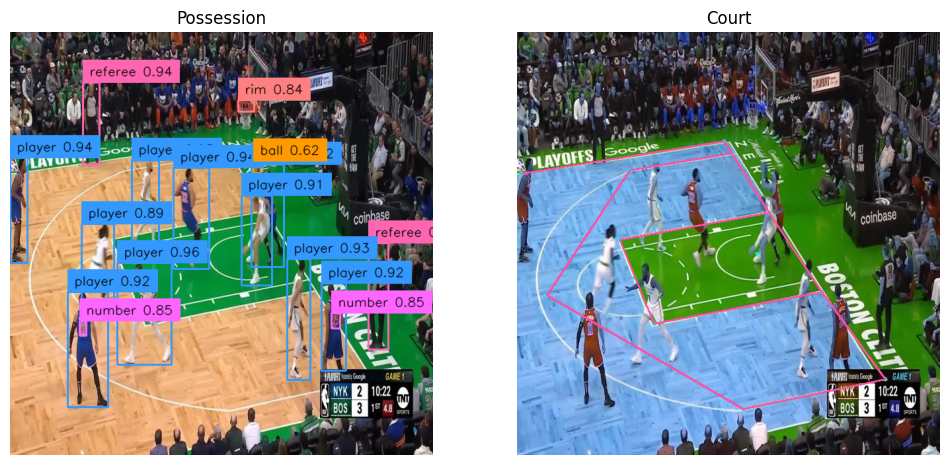

 11%|█         | 19/169 [00:00<00:06, 22.18it/s]


In [13]:
test_images = os.listdir(player_od_data + "/test/")
i = 1
for path, image, annotations in tqdm(ds):
    
    if i % 20 == 0:
        # inference
        image = Image.open(path)
        od_detections = od_model.predict(image)
        kpd_detections = kpd_model(image)

        # plotting schtuff
        image_court = Court()
        text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
        thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
        color = sv.ColorPalette.from_hex([
            "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
            "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
        ])

        # OD 
        bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
        label_annotator = sv.LabelAnnotator(
            color=color,
            text_color=sv.Color.BLACK,
            text_scale=text_scale)

        detections_labels = [
            f"{ds.classes[class_id]} {confidence:.2f}"
            for class_id, confidence
            in zip(od_detections.class_id, od_detections.confidence)
        ]

        detections_image = image.copy()
        detections_image = bbox_annotator.annotate(detections_image, od_detections)
        detections_image = label_annotator.annotate(detections_image, od_detections, detections_labels)

        # KPD
        # get kp object via supervision
        key_points = sv.KeyPoints.from_ultralytics(kpd_detections[0])

        # filter out low confidence key points
        kp_to_keep = key_points.confidence > 0.1

        # build a filtered key point object
        kp_ids = np.array([i for i in range(key_points.confidence.shape[1])])[kp_to_keep.flatten()]

        # filter down edge list to what we have
        image_court.kp_edge_list = [(edge[0]+1, edge[1]+1) for edge in image_court.kp_edge_list if edge[0] in set(kp_ids) and edge[1] in set(kp_ids)]

        kp_thresholded = key_points.xy[kp_to_keep]
        kp_confidence_thresholded = key_points.confidence[kp_to_keep]
        thresholded_key_points = sv.KeyPoints(
            xy=kp_thresholded.reshape(-1,*kp_thresholded.shape),
            class_id=key_points.class_id,
            confidence=kp_confidence_thresholded.reshape(-1,*kp_confidence_thresholded.shape)
        )

        # just plotting stuff
        kpd_image = cv2.imread(path)

        # annotate keypoints
        vertex_annotator = sv.VertexAnnotator(radius=3, color=sv.Color.YELLOW)
        kpd_image = vertex_annotator.annotate(
            scene=kpd_image,
            key_points=thresholded_key_points)

        # annotate edges
        edge_annotator = sv.EdgeAnnotator(thickness=2, edges=image_court.kp_edge_list)
        kpd_image = edge_annotator.annotate(
            scene=kpd_image,
            key_points=key_points)

        kpd_image = sv.resize_image(
            kpd_image,
            resolution_wh=(640, 640), # keep same as model input size for easier viz
            keep_aspect_ratio=True
        )

        # convert to RGB
        kpd_image = cv2.cvtColor(kpd_image, cv2.COLOR_BGR2RGB)
        sv.plot_images_grid(images=[detections_image, kpd_image], grid_size=(1, 2), titles=["Possession", "Court"])
        break
    i += 1


## Homography

First, let's define the court we want to project to.

(35, 34)
(576, 348)


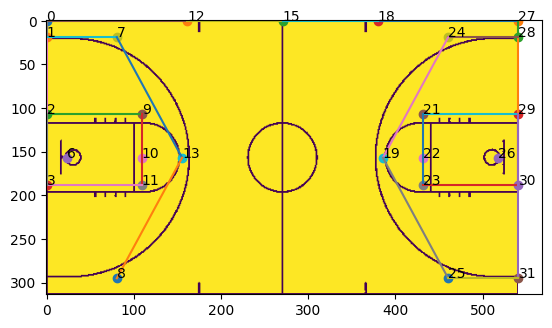

In [14]:
# the court we want to project to
# it's not a perfect match, but it's close enough
td_court = Image.open("../assets/istockphoto-1345283388-612x612.jpg")
td_court = td_court.convert("L")
td_court = td_court.point( lambda p: 255 if p > 200 else 0 )
td_court_arr = np.array(td_court)

# crop outside of court
top_left = (0, 0)
found_top_left = False
for r in range(td_court_arr.shape[0]):
    for c in range(td_court_arr.shape[1]):
        if td_court_arr[r, c] != 255:
            top_left = (c, r)
            found_top_left = True
            break
    if found_top_left:
        break

bottom_right = (td_court_arr.shape[1] - 1, td_court_arr.shape[0] - 1)
found_bottom_right = False
for r in range(td_court_arr.shape[0] - 1, -1, -1):
    for c in range(td_court_arr.shape[1] - 1, -1, -1):
        if td_court_arr[r, c] != 255:
            bottom_right = (c, r)
            found_bottom_right = True
            break
    if found_bottom_right:
        break

print(top_left)
print(bottom_right)

td_court = td_court.crop((top_left[0], top_left[1], bottom_right[0], bottom_right[1]))
td_court_arr = np.array(td_court)
width = td_court_arr.shape[1]
height = td_court_arr.shape[0]

plt.imshow(td_court)
ball_court = Court(width=width, height = height)

for idx, coord in ball_court.kp_coordinates.items():
    plt.scatter(coord[0], coord[1])
    plt.text(coord[0], coord[1], idx)
for edge in ball_court.kp_edge_list:
    plt.plot([ball_court.kp_coordinates[edge[0]][0], ball_court.kp_coordinates[edge[1]][0]], [ball_court.kp_coordinates[edge[0]][1], ball_court.kp_coordinates[edge[1]][1]])

plt.show()

Now we can perform homography!

  0%|          | 0/169 [00:00<?, ?it/s]


0: 640x640 1 court, 311.8ms
Speed: 2.0ms preprocess, 311.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


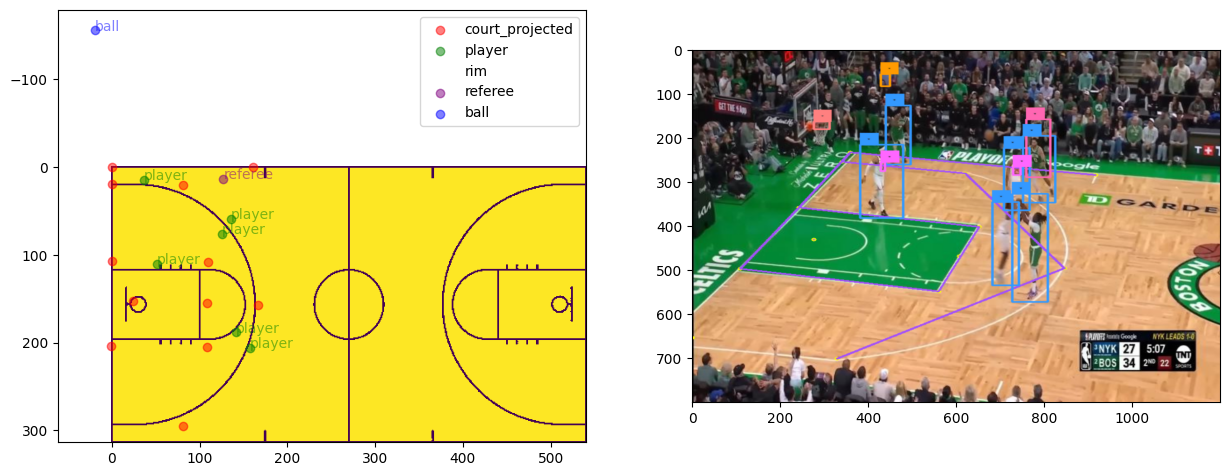

  2%|▏         | 3/169 [00:00<00:39,  4.25it/s]


0: 640x640 1 court, 370.1ms
Speed: 1.2ms preprocess, 370.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


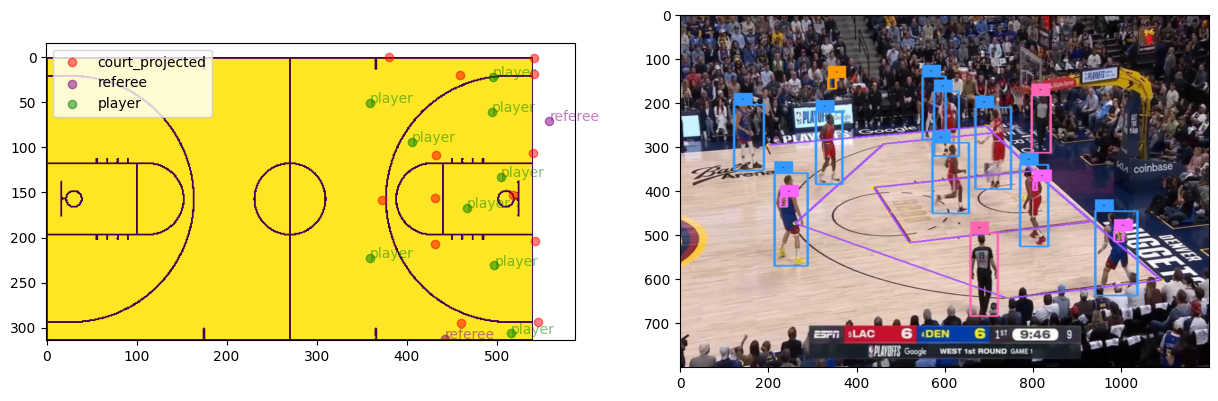

 25%|██▍       | 42/169 [00:01<00:03, 35.21it/s]


0: 640x640 1 court, 328.5ms
Speed: 1.9ms preprocess, 328.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


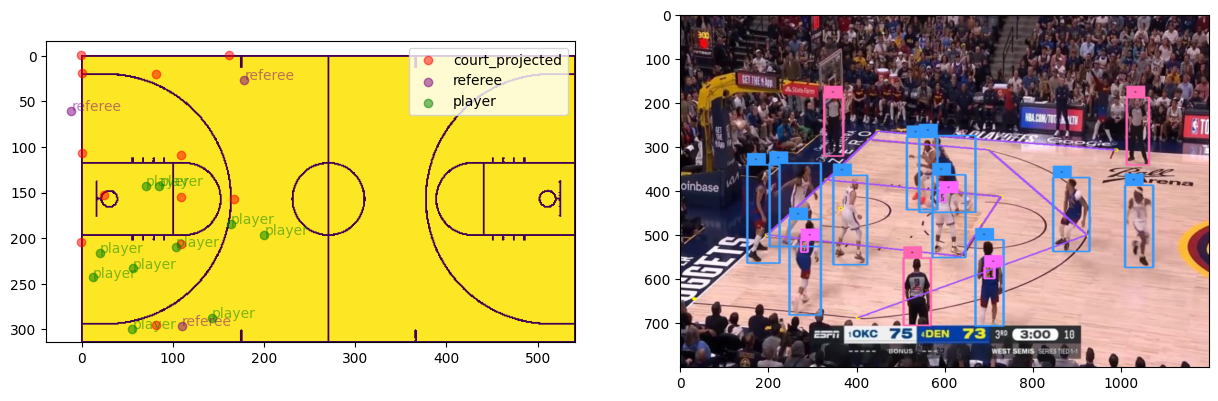

 30%|███       | 51/169 [00:02<00:05, 19.76it/s]


0: 640x640 1 court, 342.1ms
Speed: 1.3ms preprocess, 342.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


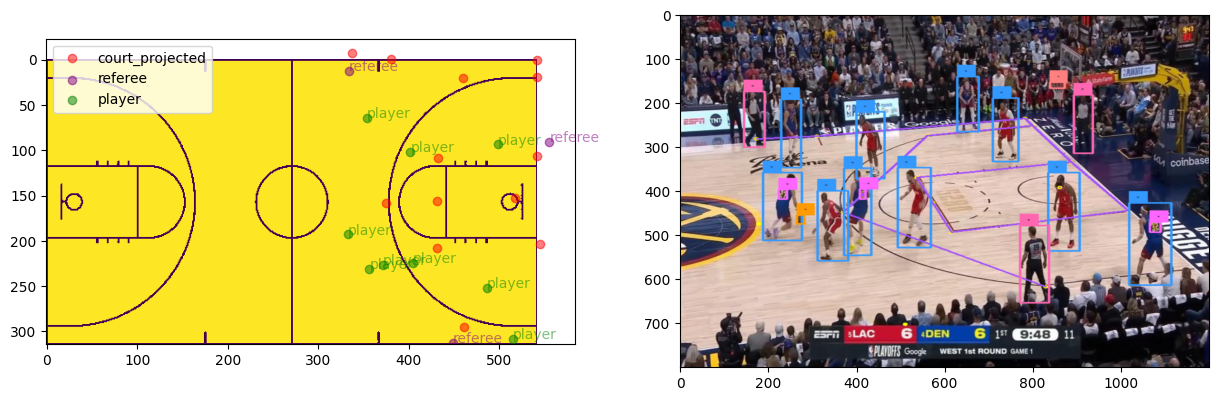

 49%|████▊     | 82/169 [00:03<00:02, 31.63it/s]


0: 640x640 1 court, 312.6ms
Speed: 1.3ms preprocess, 312.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


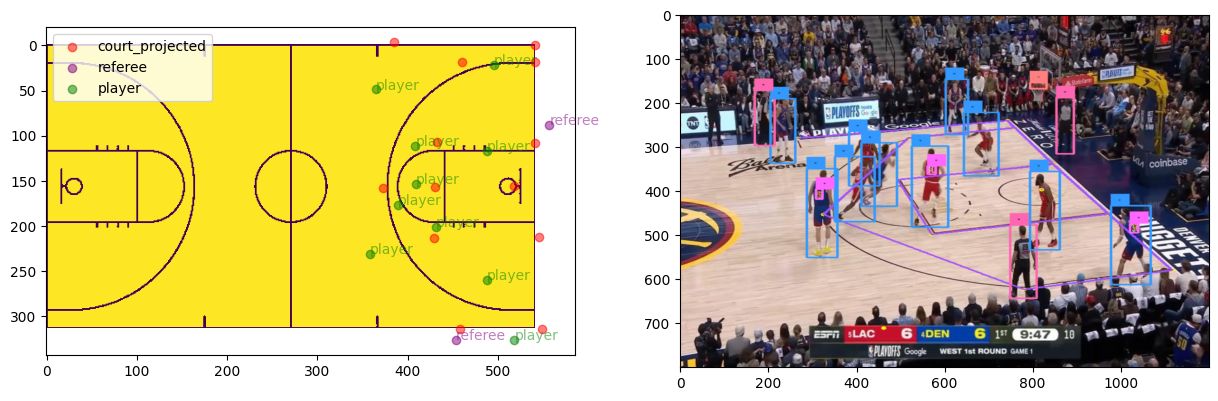

 54%|█████▍    | 91/169 [00:03<00:03, 25.09it/s]


0: 640x640 1 court, 378.1ms
Speed: 1.1ms preprocess, 378.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


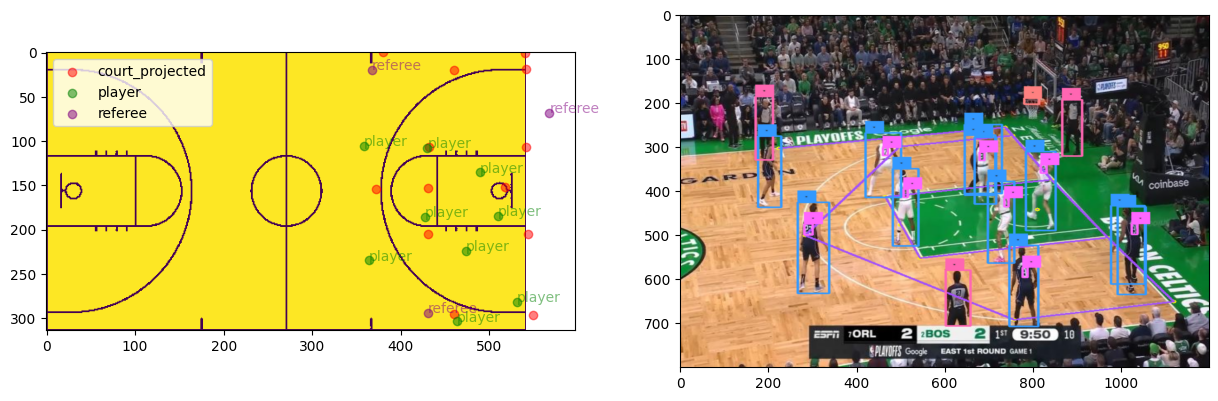

 61%|██████    | 103/169 [00:04<00:02, 22.21it/s]


0: 640x640 1 court, 396.0ms
Speed: 1.4ms preprocess, 396.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


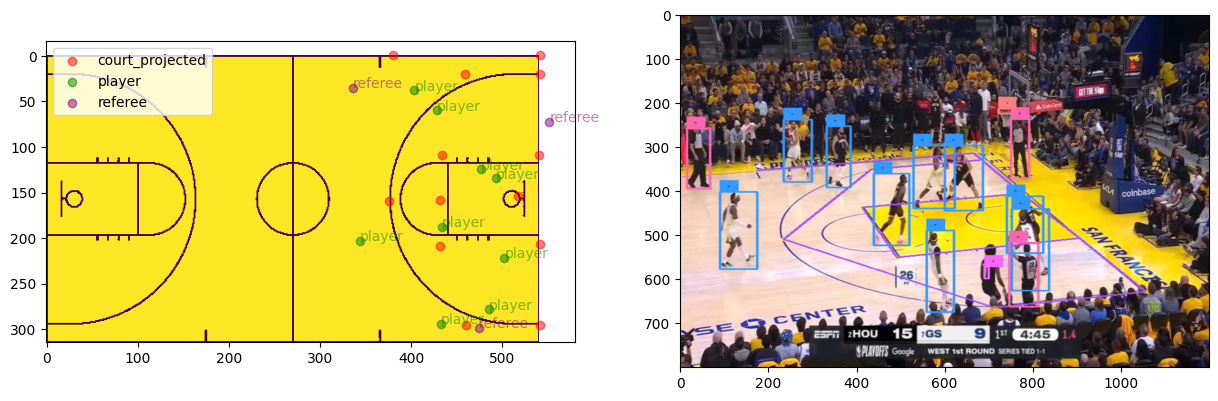

 73%|███████▎  | 123/169 [00:05<00:01, 24.30it/s]


0: 640x640 1 court, 364.0ms
Speed: 1.1ms preprocess, 364.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


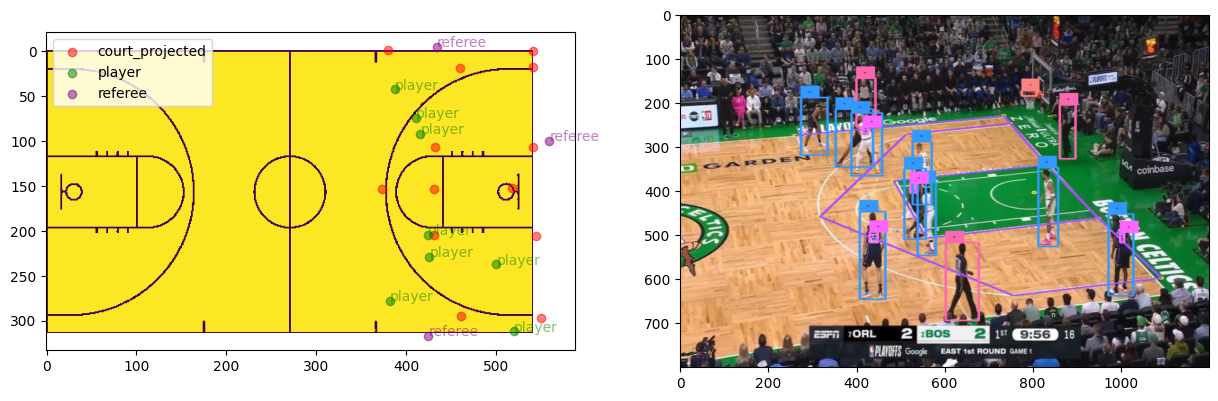

 85%|████████▍ | 143/169 [00:05<00:01, 25.97it/s]


0: 640x640 1 court, 355.9ms
Speed: 1.7ms preprocess, 355.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


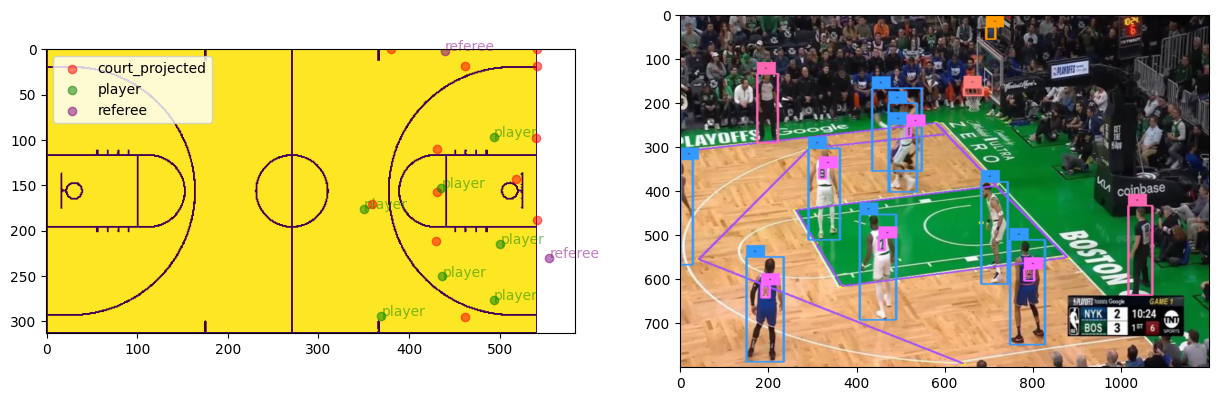

100%|██████████| 169/169 [00:06<00:00, 25.31it/s]


In [19]:
for path, image, annotations in tqdm(ds):
    
    if i % 20 == 0:
        # inference
        image_court = Court()
        image = cv2.imread(path)
        od_detections = od_model.predict(image)
        kpd_detections = kpd_model(image)

        # kp coords
        key_points = sv.KeyPoints.from_ultralytics(kpd_detections[0])
        kp_to_keep = key_points.confidence > 0.1
        kp_ids = np.array([i for i in range(key_points.confidence.shape[1])])[kp_to_keep.flatten()]
        image_court.kp_edge_list = [(edge[0]+1, edge[1]+1) for edge in image_court.kp_edge_list if edge[0] in set(kp_ids) and edge[1] in set(kp_ids)]
        kp_thresholded = key_points.xy[kp_to_keep]

        kp_confidence_thresholded = key_points.confidence[kp_to_keep]
        thresholded_key_points = sv.KeyPoints(
            xy=kp_thresholded.reshape(-1,*kp_thresholded.shape),
            class_id=key_points.class_id,
            confidence=kp_confidence_thresholded.reshape(-1,*kp_confidence_thresholded.shape)
        )        

        # filter out any points that are not in court
        id_kp = []
        for idx, kp in zip(kp_ids, kp_thresholded):
            if idx in image_court.kp_coordinates:
                id_kp.append((idx, kp))

        ###### perform homography ######
        # ON COURT
        source = np.array([x for _, x in id_kp])
        source = np.concatenate([source, np.ones((source.shape[0], 1))], axis=1)
        destination = np.array([ball_court.kp_coordinates[int(idx)] for idx in kp_ids if idx in ball_court.kp_coordinates])
        destination = np.concatenate([destination, np.ones((destination.shape[0], 1))], axis=1)

        H, _ = cv2.findHomography(source, destination, cv2.RANSAC)
        projected = H @ source.T
        projected = projected.T

        # ON PLAYERS
        mean_player_pos = np.concatenate(
            [od_detections.xyxy[:, [0, 2]].mean(axis=1).reshape(-1, 1),
            od_detections.xyxy[:, 3].reshape(-1, 1),
            np.ones((od_detections.xyxy.shape[0], 1))],
            axis=1
        )
        mean_player_pos_projected = H @ mean_player_pos.T
        mean_player_pos_projected = mean_player_pos_projected.T

        ###### build plots ######
        plt.figure(figsize=(15, 7))

        # HOMOGRAPHY PLOT
        plt.subplot(1, 2, 1)
        plt.imshow(td_court)

        # for idx, coord in zip(kp_ids, destination):
            # plt.scatter(coord[0]/coord[2], coord[1]/coord[2], color="blue", alpha = 0.5, label = 'court_actual')
            # plt.text(coord[0]/coord[2], coord[1]/coord[2], idx, color='blue', alpha = 0.5)

        for idx, coord in zip(kp_ids, projected):
            plt.scatter(coord[0]/coord[2], coord[1]/coord[2], color="red", alpha = 0.5, label = 'court_projected')
            # plt.text(coord[0]/coord[2], coord[1]/coord[2], idx, color='red', alpha = 0.5)

        for idx, coord, class_id in zip(kp_ids, mean_player_pos_projected, od_detections.class_id):
            if ds.classes[class_id] == 'player':
                class_color = 'green'
            elif ds.classes[class_id] == 'ball':
                class_color = 'blue' 
            elif ds.classes[class_id] == 'referee':
                class_color = 'purple'
            elif ds.classes[class_id] == 'rim':
                class_color = 'white'                
            else:
                continue
            plt.scatter(coord[0]/coord[2], coord[1]/coord[2], color=class_color, alpha = 0.5, label = ds.classes[class_id])
            plt.text(coord[0]/coord[2], coord[1]/coord[2], ds.classes[class_id], color=class_color, alpha = 0.5)

        # remove duplicate labels
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        ###### KPD+OD PLOT ######
        kpd_image = cv2.imread(path)
        text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.shape)
        thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.shape)
        color = sv.ColorPalette.from_hex([
            "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
            "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
        ])
        
        # annotate keypoints
        vertex_annotator = sv.VertexAnnotator(radius=3, color=sv.Color.YELLOW)
        kpd_image = vertex_annotator.annotate(scene=kpd_image, key_points=thresholded_key_points)

        # annotate edges
        edge_annotator = sv.EdgeAnnotator(thickness=2, edges=image_court.kp_edge_list)
        kpd_image = edge_annotator.annotate(scene=kpd_image, key_points=key_points)

        # annotate bbox
        bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
        detections_labels = [
            f"{ds.classes[class_id]} {confidence:.2f}"
            for class_id, confidence
            in zip(od_detections.class_id, od_detections.confidence)
        ]
        kpd_image = bbox_annotator.annotate(kpd_image, od_detections)

        # annotate labels
        label_annotator = sv.LabelAnnotator(
            color=color,
            text_color=sv.Color.BLACK,
            text_scale=text_scale)
        label_annotator.annotate(kpd_image, od_detections, detections_labels)

        kpd_image = sv.resize_image(
            kpd_image,
            resolution_wh=(1200, 800), # keep same as model input size for easier viz
            keep_aspect_ratio=False
        )

        # convert to RGB
        kpd_image = cv2.cvtColor(kpd_image, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 2, 2)
        plt.imshow(kpd_image)
        plt.show()

    i += 1